# ==========================================================
# 6. Data Cleaning
# ==========================================================



The objective of this notebook is to transform the raw Home Credit dataset into a clean, consistent, and analysis-ready dataset.

The cleaning process focuses on:

- Duplicate detection
- Missing value treatment
- Incorrect value detection
- Special value handling
- Outlier analysis
- Data type optimization

The cleaned dataset generated in this notebook will serve as the input for the Feature Engineering stage.

 Notebook 03: Data Cleaning

This notebook corresponds to **Section 6 (Data Cleaning)** of the overall Credit Risk Prediction project. The section numbering follows the structure of the complete project report to maintain consistency across all notebooks.

# 6.1 Import Libraries

In [164]:
# Import Libraries

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 6.2 Load Dataset

In [165]:
# Load Dataset

df = pd.read_csv("../data/raw/application_train.csv")

print("Dataset Shape :", df.shape)
df.head()

Dataset Shape : (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

# 6.3 Dataset Copy

In [166]:
# Create a Copy

df_clean = df.copy()

print("Working Copy Created Successfully.")

Working Copy Created Successfully.


# 6.4 Duplicate Record Analysis

Duplicate records can negatively impact model performance by introducing bias and overrepresenting certain observations. In this section, we identify duplicate rows and duplicate customer IDs (`SK_ID_CURR`) to ensure each loan application is represented only once.

In [167]:
print(f"Dataset Shape: {df_clean.shape}")

Dataset Shape: (307511, 122)


In [168]:
# Check duplicate rows

duplicate_rows = df_clean.duplicated().sum()

print(f"Number of Duplicate Rows: {duplicate_rows}")

Number of Duplicate Rows: 0


In [169]:
if duplicate_rows > 0:
    display(df_clean[df_clean.duplicated()].head())
else:
    print("No duplicate rows found.")

No duplicate rows found.


In [170]:
duplicate_ids = df_clean["SK_ID_CURR"].duplicated().sum()

print(f"Duplicate Customer IDs: {duplicate_ids}")

Duplicate Customer IDs: 0


In [171]:
if duplicate_ids > 0:
    display(
        df_clean[df_clean["SK_ID_CURR"].duplicated(keep=False)]
        .sort_values("SK_ID_CURR")
        .head(10)
    )
else:
    print("All Customer IDs are unique.")

All Customer IDs are unique.


In [172]:
# Remove duplicate rows if present

before_rows = df_clean.shape[0]

df_clean = df_clean.drop_duplicates()

after_rows = df_clean.shape[0]

print(f"Rows Before Cleaning : {before_rows}")
print(f"Rows After Cleaning  : {after_rows}")
print(f"Rows Removed         : {before_rows - after_rows}")

Rows Before Cleaning : 307511
Rows After Cleaning  : 307511
Rows Removed         : 0


In [173]:
print(f"Final Dataset Shape: {df_clean.shape}")

Final Dataset Shape: (307511, 122)


### Interpretation

- No duplicate rows were identified in the dataset.
- Each customer ID (`SK_ID_CURR`) is unique, indicating that every observation corresponds to a distinct loan application.
- Since no duplicate records were found, no rows were removed during this step.
- This confirms that the dataset maintains record-level integrity, allowing subsequent preprocessing and modeling to proceed without concerns about duplicate observations introducing bias.

# 6.5 Missing Value Treatment

Missing values are common in real-world financial datasets and must be handled carefully. Improper treatment may introduce bias, reduce predictive performance, or remove valuable information.

In this section, we:

- Quantify missing values.
- Identify variables with high missingness.
- Classify features based on the percentage of missing data.
- Decide an appropriate treatment strategy for each category.

## 6.5.1 Missing Value Overview

In [174]:
# Calculate missing values

missing_values = df_clean.isnull().sum()

missing_percentage = (missing_values / len(df_clean)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

missing_summary = missing_summary[
    missing_summary["Missing Values"] > 0
].sort_values(
    by="Missing Percentage",
    ascending=False
)

print(f"Columns with Missing Values: {missing_summary.shape[0]}")

missing_summary.head(20)

Columns with Missing Values: 67


,Missing Values,Missing Percentage
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_AVG,214865,69.872297
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


In [175]:
#Display summary
missing_summary.head(20)

,Missing Values,Missing Percentage
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_AVG,214865,69.872297
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


In [176]:
# Summary statistics
print(f"Total Features : {df_clean.shape[1]}")
print(f"Features with Missing Values : {missing_summary.shape[0]}")
print(f"Features without Missing Values : {df_clean.shape[1] - missing_summary.shape[0]}")

Total Features : 122
Features with Missing Values : 67
Features without Missing Values : 55


## 6.5.2 Missing Value Visualization

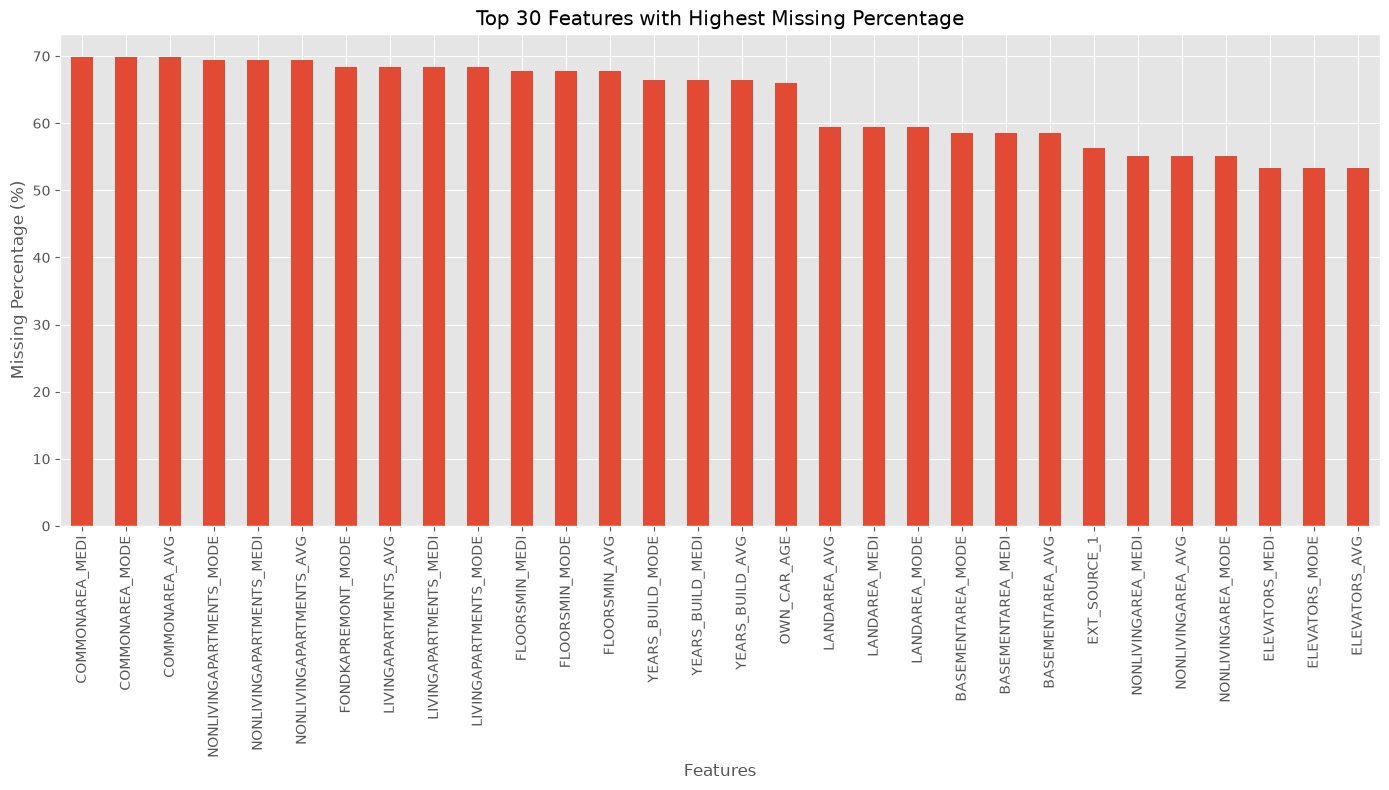

In [177]:
#Bar chart
plt.figure(figsize=(14,8))

missing_summary["Missing Percentage"].head(30).plot(kind="bar")

plt.title("Top 30 Features with Highest Missing Percentage")
plt.ylabel("Missing Percentage (%)")
plt.xlabel("Features")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

### Interpretation

The chart displays the **top 30 features with the highest percentage of missing values** in the Home Credit Default Risk dataset.

Several variables exhibit missing rates exceeding **50%**, with `COMMONAREA_*`, `NONLIVINGAPARTMENTS_*`, `LIVINGAPARTMENTS_*`, `FLOORSMIN_*`, and `YEARS_BUILD_*` having approximately **65–70% missing values**. Most of these variables describe the physical characteristics of residential properties.

The variable `OWN_CAR_AGE` also contains a high proportion of missing values. This is expected because applicants who do not own a vehicle naturally have no associated car age, making the missing values meaningful rather than erroneous.

Similarly, variables such as `LANDAREA_*`, `BASEMENTAREA_*`, `NONLIVINGAREA_*`, `ELEVATORS_*`, and `EXT_SOURCE_1` also exhibit substantial missingness. These variables are primarily related to property attributes or external credit information, which may not be available for every applicant.

The concentration of missing values within specific groups of variables indicates that the missingness is **systematic rather than random**. In many cases, the absence of information reflects applicant characteristics or unavailable external records instead of poor data quality.

Based on this analysis, missing value treatment should be guided by business understanding rather than applying a uniform imputation strategy. Variables with extremely high missingness require careful evaluation to determine whether they should be removed, retained, or imputed using appropriate methods.

#### Business Insight

The high missingness observed in property-related variables suggests that detailed housing information is not available for many applicants. This may occur because some applicants do not own property, certain property characteristics were not collected, or the information was unavailable during loan processing.

Consequently, missing values in these variables may themselves contain predictive information and should not automatically be treated as data quality issues.

## 6.5.3 Categorize Missing Features

In [178]:
# Creating categories

low_missing = missing_summary[
    missing_summary["Missing Percentage"] < 5
]

moderate_missing = missing_summary[
    (missing_summary["Missing Percentage"] >= 5) &
    (missing_summary["Missing Percentage"] < 30)
]

high_missing = missing_summary[
    (missing_summary["Missing Percentage"] >= 30) &
    (missing_summary["Missing Percentage"] < 60)
]

very_high_missing = missing_summary[
    missing_summary["Missing Percentage"] >= 60
]

In [179]:
#Display categories
print(f"Low Missing (<5%)            : {len(low_missing)}")
print(f"Moderate Missing (5-30%)     : {len(moderate_missing)}")
print(f"High Missing (30-60%)        : {len(high_missing)}")
print(f"Very High Missing (>60%)     : {len(very_high_missing)}")

Low Missing (<5%)            : 10
Moderate Missing (5-30%)     : 7
High Missing (30-60%)        : 33
Very High Missing (>60%)     : 17


In [180]:
print("Low Missing Features")
display(low_missing)

print("Moderate Missing Features")
display(moderate_missing)

print("High Missing Features")
display(high_missing)

print("Very High Missing Features")
display(very_high_missing)

Low Missing Features


,Missing Values,Missing Percentage
NAME_TYPE_SUITE,1292,0.420148
DEF_30_CNT_SOCIAL_CIRCLE,1021,0.332021
DEF_60_CNT_SOCIAL_CIRCLE,1021,0.332021
OBS_30_CNT_SOCIAL_CIRCLE,1021,0.332021
OBS_60_CNT_SOCIAL_CIRCLE,1021,0.332021
EXT_SOURCE_2,660,0.214626
AMT_GOODS_PRICE,278,0.090403
AMT_ANNUITY,12,0.003902
CNT_FAM_MEMBERS,2,0.000650
DAYS_LAST_PHONE_CHANGE,1,0.000325


Moderate Missing Features


,Missing Values,Missing Percentage
EXT_SOURCE_3,60965,19.825307
AMT_REQ_CREDIT_BUREAU_WEEK,41519,13.501631
AMT_REQ_CREDIT_BUREAU_MON,41519,13.501631
AMT_REQ_CREDIT_BUREAU_HOUR,41519,13.501631
AMT_REQ_CREDIT_BUREAU_YEAR,41519,13.501631
AMT_REQ_CREDIT_BUREAU_QRT,41519,13.501631
AMT_REQ_CREDIT_BUREAU_DAY,41519,13.501631


High Missing Features


,Missing Values,Missing Percentage
LANDAREA_AVG,182590,59.376738
LANDAREA_MEDI,182590,59.376738
LANDAREA_MODE,182590,59.376738
BASEMENTAREA_MODE,179943,58.515956
BASEMENTAREA_MEDI,179943,58.515956
BASEMENTAREA_AVG,179943,58.515956
EXT_SOURCE_1,173378,56.381073
NONLIVINGAREA_MEDI,169682,55.179164
NONLIVINGAREA_AVG,169682,55.179164
NONLIVINGAREA_MODE,169682,55.179164


Very High Missing Features


,Missing Values,Missing Percentage
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_AVG,214865,69.872297
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


### Interpretation

The Home Credit dataset contains missing values across several features. However, the extent of missingness varies considerably.

- Features with **low missingness (<5%)** are generally suitable for imputation using statistical methods such as the median or mode.
- Features with **moderate missingness (5–30%)** require careful consideration to preserve meaningful information while minimizing bias.
- Features with **high missingness (30–60%)** may still contain valuable predictive signals but require advanced imputation techniques or business justification.
- Features with **very high missingness (>60%)** are candidates for removal if they provide limited analytical value, although domain knowledge should guide the final decision.

Rather than removing all incomplete observations, an appropriate treatment strategy will be applied based on the level of missingness and the business relevance of each feature.

### 6.5.4 Remove Features with Very High Missingness

Rather than removing all variables with high missingness based on a fixed threshold, each feature is evaluated individually. In credit risk datasets, missing values frequently represent the absence of previous financial activity rather than poor data quality.

Therefore, features are removed only when they provide limited analytical value and excessive missingness outweighs their potential predictive usefulness.

In [181]:
# Review features with very high missing values

very_high_missing

,Missing Values,Missing Percentage
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_AVG,214865,69.872297
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


In [182]:
#print feature name
print("Features with Very High Missingness (>60%)")

for column in very_high_missing.index:
    print(column)

Features with Very High Missingness (>60%)
COMMONAREA_MEDI
COMMONAREA_MODE
COMMONAREA_AVG
NONLIVINGAPARTMENTS_MODE
NONLIVINGAPARTMENTS_MEDI
NONLIVINGAPARTMENTS_AVG
FONDKAPREMONT_MODE
LIVINGAPARTMENTS_AVG
LIVINGAPARTMENTS_MEDI
LIVINGAPARTMENTS_MODE
FLOORSMIN_MEDI
FLOORSMIN_MODE
FLOORSMIN_AVG
YEARS_BUILD_MODE
YEARS_BUILD_MEDI
YEARS_BUILD_AVG
OWN_CAR_AGE


### Decision

Although several variables contain more than 60% missing values, they are retained for further analysis.

In credit risk datasets, missing values often carry business meaning rather than indicating poor data quality. For example, the absence of vehicle age may simply indicate that an applicant does not own a car.

Therefore, no features are removed solely on the basis of high missingness. Appropriate imputation and feature engineering techniques will be applied in subsequent steps.

In [183]:
print("No features were removed based solely on missing percentage.")

print(f"Dataset Shape : {df_clean.shape}")

No features were removed based solely on missing percentage.
Dataset Shape : (307511, 122)


### 6.5.5 Numerical Feature Imputation

Numerical variables were not imputed using a single universal strategy. Instead, imputation methods were selected based on the business meaning of each feature.

- Financial variables were imputed using the median because they are continuous and often exhibit skewed distributions.
- Property-related variables were intentionally left unchanged, as missing values frequently indicate the absence of a property characteristic rather than missing information.
- Vehicle age was also retained as missing because a missing value generally indicates that the applicant does not own a vehicle.

This approach preserves valuable business information while preparing appropriate variables for predictive modeling.

In [184]:
# Numerical features with missing values

numerical_missing = (
    df_clean
    .select_dtypes(include=['int64', 'float64'])
    .columns
)

numerical_missing = [
    col for col in numerical_missing
    if df_clean[col].isnull().sum() > 0
]

print(f"Numerical Features with Missing Values: {len(numerical_missing)}")

Numerical Features with Missing Values: 61


In [185]:
#Define Finance Variable 
financial_features = [

    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "AMT_CREDIT",
    "AMT_INCOME_TOTAL",

    "CNT_FAM_MEMBERS",

    "DAYS_LAST_PHONE_CHANGE",

    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3"

]

In [186]:
#Median Imputation
for column in financial_features:

    if column in df_clean.columns:

        median_value = df_clean[column].median()

        df_clean[column] = df_clean[column].fillna(median_value)

print("Financial numerical variables imputed successfully.")

Financial numerical variables imputed successfully.


In [187]:
#Check Remaining Missing Features
remaining_numeric = (
    df_clean[numerical_missing]
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

remaining_numeric[remaining_numeric > 0].head(20)

COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
COMMONAREA_MEDI             214865
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_AVG     213514
NONLIVINGAPARTMENTS_MEDI    213514
LIVINGAPARTMENTS_MODE       210199
LIVINGAPARTMENTS_AVG        210199
LIVINGAPARTMENTS_MEDI       210199
FLOORSMIN_MODE              208642
FLOORSMIN_MEDI              208642
FLOORSMIN_AVG               208642
YEARS_BUILD_AVG             204488
YEARS_BUILD_MEDI            204488
YEARS_BUILD_MODE            204488
OWN_CAR_AGE                 202929
LANDAREA_AVG                182590
LANDAREA_MODE               182590
LANDAREA_MEDI               182590
BASEMENTAREA_AVG            179943
dtype: int64

#### Interpretation

Median imputation was applied only to financial and credit-related numerical variables where missing values are likely due to incomplete information.

Property-related variables and vehicle age were intentionally preserved because their missing values represent meaningful business information rather than random data quality issues.

### 6.5.6 Categorical Feature Imputation

Categorical variables were reviewed individually before imputation.

Most categorical features with missing values were imputed using the mode, as these missing values are relatively small in proportion.

However, variables where missing values carry business meaning should ideally be treated separately or encoded during feature engineering.

In [188]:
#Identify Categorical Variables
categorical_missing = [

    col

    for col in df_clean.select_dtypes(include="object").columns

    if df_clean[col].isnull().sum() > 0

]

print(f"Categorical Features with Missing Values: {len(categorical_missing)}")

Categorical Features with Missing Values: 6


In [189]:
#Review Missing Counts
df_clean[categorical_missing].isnull().sum().sort_values(ascending=False)

FONDKAPREMONT_MODE     210295
WALLSMATERIAL_MODE     156341
HOUSETYPE_MODE         154297
EMERGENCYSTATE_MODE    145755
OCCUPATION_TYPE         96391
NAME_TYPE_SUITE          1292
dtype: int64

In [190]:
#Mode Imputation
for column in categorical_missing:

    mode_value = df_clean[column].mode()[0]

    df_clean[column] = df_clean[column].fillna(mode_value)

print("Categorical variables imputed successfully.")

Categorical variables imputed successfully.


In [191]:
#Verify Remaining Categorical Missing Values
remaining_cat = (
    df_clean[categorical_missing]
    .isnull()
    .sum()
)

remaining_cat[remaining_cat > 0]

Series([], dtype: int64)

#### Interpretation

Categorical variables were imputed using the most frequent category (mode). Since the proportion of missing values in these variables is relatively small, mode imputation preserves the existing category distribution while ensuring a complete dataset for downstream modeling.

### 6.5.7 Verify Missing Value Treatment

A final verification is performed after the imputation process to confirm that financial and categorical variables have been treated appropriately. Any remaining missing values are reviewed to ensure they correspond to variables where missingness has business significance and has been intentionally retained.

In [192]:
#Total Remaining Missing Values
total_missing = df_clean.isnull().sum().sum()

print(f"Total Remaining Missing Values: {total_missing:,}")

Total Remaining Missing Values: 8,152,798


In [193]:
#Remaining Features
remaining_missing = (
    df_clean.isnull()
    .sum()
    .sort_values(ascending=False)
)

remaining_missing = remaining_missing[remaining_missing > 0]

remaining_missing

COMMONAREA_AVG                  214865
COMMONAREA_MODE                 214865
COMMONAREA_MEDI                 214865
NONLIVINGAPARTMENTS_MEDI        213514
NONLIVINGAPARTMENTS_MODE        213514
NONLIVINGAPARTMENTS_AVG         213514
LIVINGAPARTMENTS_AVG            210199
LIVINGAPARTMENTS_MODE           210199
LIVINGAPARTMENTS_MEDI           210199
FLOORSMIN_AVG                   208642
FLOORSMIN_MODE                  208642
FLOORSMIN_MEDI                  208642
YEARS_BUILD_AVG                 204488
YEARS_BUILD_MODE                204488
YEARS_BUILD_MEDI                204488
OWN_CAR_AGE                     202929
LANDAREA_MODE                   182590
LANDAREA_MEDI                   182590
LANDAREA_AVG                    182590
BASEMENTAREA_AVG                179943
BASEMENTAREA_MEDI               179943
BASEMENTAREA_MODE               179943
NONLIVINGAREA_MEDI              169682
NONLIVINGAREA_MODE              169682
NONLIVINGAREA_AVG               169682
ELEVATORS_AVG            

In [194]:
#Summary
print("=" * 60)
print("Missing Value Verification Summary")
print("=" * 60)

print(f"Dataset Shape              : {df_clean.shape}")
print(f"Remaining Missing Features : {len(remaining_missing)}")
print(f"Remaining Missing Values   : {total_missing:,}")

Missing Value Verification Summary
Dataset Shape              : (307511, 122)
Remaining Missing Features : 54
Remaining Missing Values   : 8,152,798


In [195]:
#Explain Remaining Missing Values
remaining_missing.head(20)

COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
COMMONAREA_MEDI             214865
NONLIVINGAPARTMENTS_MEDI    213514
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_AVG     213514
LIVINGAPARTMENTS_AVG        210199
LIVINGAPARTMENTS_MODE       210199
LIVINGAPARTMENTS_MEDI       210199
FLOORSMIN_AVG               208642
FLOORSMIN_MODE              208642
FLOORSMIN_MEDI              208642
YEARS_BUILD_AVG             204488
YEARS_BUILD_MODE            204488
YEARS_BUILD_MEDI            204488
OWN_CAR_AGE                 202929
LANDAREA_MODE               182590
LANDAREA_MEDI               182590
LANDAREA_AVG                182590
BASEMENTAREA_AVG            179943
dtype: int64

#### Interpretation

Financial and categorical variables with missing values were treated using appropriate imputation techniques. However, missing values in several property-related and vehicle-related variables were intentionally retained because they represent meaningful business information rather than random data quality issues.

For example, a missing value in `OWN_CAR_AGE` generally indicates that the applicant does not own a vehicle, while missing values in apartment-related variables often indicate the absence of corresponding property information.

Retaining these missing values preserves valuable predictive signals that can be leveraged during feature engineering and model development.

# 6.6 Incorrect Data Detection

### 6.6.1 Numerical Value Validation

This section validates key numerical variables to identify impossible or inconsistent values that may affect downstream analysis and model performance.

The validation focuses on financial variables, family information, and demographic attributes to ensure they fall within reasonable business limits.

In [196]:
#Define Variable
numerical_checks = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS"
]

In [197]:
#Check for Negative Values
print("=" * 70)
print("Negative Value Validation")
print("=" * 70)

for column in numerical_checks:

    negative = (df_clean[column] < 0).sum()

    print(f"{column:<25} : {negative}")

Negative Value Validation
AMT_INCOME_TOTAL          : 0
AMT_CREDIT                : 0
AMT_ANNUITY               : 0
AMT_GOODS_PRICE           : 0
CNT_CHILDREN              : 0
CNT_FAM_MEMBERS           : 0


In [198]:
#Check Zero Values
print("=" * 70)
print("Zero Value Validation")
print("=" * 70)

for column in numerical_checks:

    zero = (df_clean[column] == 0).sum()

    print(f"{column:<25} : {zero}")

Zero Value Validation
AMT_INCOME_TOTAL          : 0
AMT_CREDIT                : 0
AMT_ANNUITY               : 0
AMT_GOODS_PRICE           : 0
CNT_CHILDREN              : 215371
CNT_FAM_MEMBERS           : 0


In [199]:
#Descriptive Statistics
df_clean[numerical_checks].describe().T

,count,mean,std,min,25%,50%,75%,max
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
AMT_ANNUITY,307511.0,27108.487841,14493.461065,1615.5,16524.0,24903.0,34596.0,258025.5
AMT_GOODS_PRICE,307511.0,538316.294367,369288.982246,40500.0,238500.0,450000.0,679500.0,4050000.0
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
CNT_FAM_MEMBERS,307511.0,2.152664,0.910679,1.0,2.0,2.0,3.0,20.0


### 6.6.2 Categorical Value Validation

Categorical variables are examined to verify that category labels are consistent and that no unexpected values are present after the data cleaning process.

In [200]:
#Validate Categories
categorical_checks = [
    "CODE_GENDER",
    "NAME_CONTRACT_TYPE",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY"
]

for column in categorical_checks:

    print("=" * 70)
    print(column)
    print(df_clean[column].value_counts(dropna=False))

CODE_GENDER
CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64
NAME_CONTRACT_TYPE
NAME_CONTRACT_TYPE
Cash loans         278232
Revolving loans     29279
Name: count, dtype: int64
FLAG_OWN_CAR
FLAG_OWN_CAR
N    202924
Y    104587
Name: count, dtype: int64
FLAG_OWN_REALTY
FLAG_OWN_REALTY
Y    213312
N     94199
Name: count, dtype: int64


> **Note:**  
> The `CODE_GENDER` variable contains four observations labeled `XNA`, representing an unspecified gender category. Because these records account for less than 0.002% of the dataset, they will be handled during feature engineering rather than removed at this stage.

## 6.6.3 Data Consistency Checks

In [201]:
print("=" * 70)
print("Family Size Consistency Check")
print("=" * 70)

invalid_family = (
    df_clean["CNT_FAM_MEMBERS"] <
    df_clean["CNT_CHILDREN"]
).sum()

print(f"Records where family members < children: {invalid_family}")

Family Size Consistency Check
Records where family members < children: 0


#### Interpretation

The dataset was validated for incorrect numerical values, inconsistent categorical labels, and basic logical relationships between variables.

No invalid negative values were detected in key financial variables, categorical labels remained consistent, and the family composition variables satisfied expected logical constraints. These checks indicate that the dataset is internally consistent and suitable for further preprocessing.

# 6.7 Special Value Handling

### 6.7.1 DAYS_EMPLOYED Placeholder Analysis

The `DAYS_EMPLOYED` feature records the number of days an applicant has been employed before the loan application.

A value of **365243** is a known placeholder in the Home Credit dataset and does not represent actual employment duration. According to the dataset documentation and community analysis, this value indicates missing or unavailable employment information.

The placeholder will be identified, analyzed, and replaced with `NaN` to prevent it from distorting subsequent analyses and feature engineering.

In [202]:
# Summary statistics for DAYS_EMPLOYED

df_clean["DAYS_EMPLOYED"].describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

In [203]:
#Count Placeholder Values
placeholder_value = 365243

placeholder_count = (
    df_clean["DAYS_EMPLOYED"] == placeholder_value
).sum()

placeholder_percentage = (
    placeholder_count / len(df_clean)
) * 100

print(f"Placeholder Value      : {placeholder_value}")
print(f"Number of Records      : {placeholder_count:,}")
print(f"Percentage of Dataset  : {placeholder_percentage:.2f}%")

Placeholder Value      : 365243
Number of Records      : 55,374
Percentage of Dataset  : 18.01%


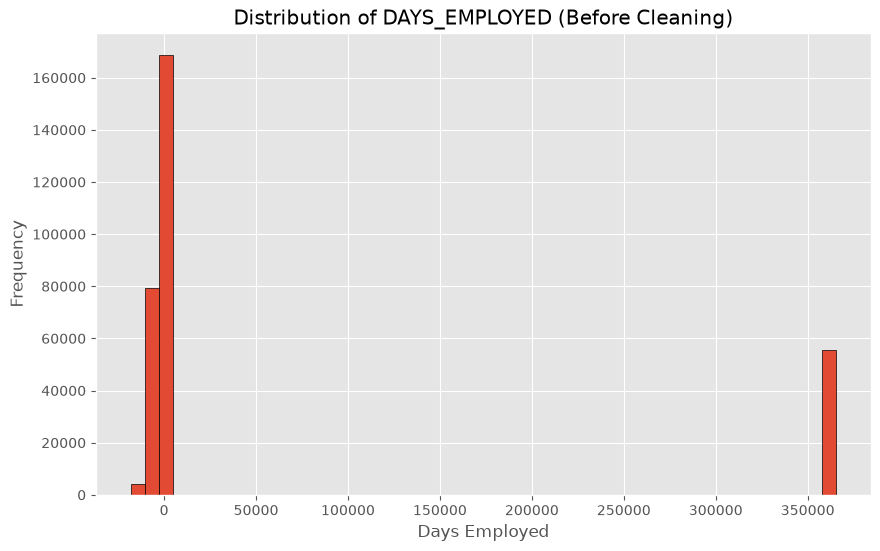

In [204]:
#Visualize the Distribution 
plt.figure(figsize=(10,6))

plt.hist(
    df_clean["DAYS_EMPLOYED"],
    bins=50,
    edgecolor="black"
)

plt.title("Distribution of DAYS_EMPLOYED (Before Cleaning)")
plt.xlabel("Days Employed")
plt.ylabel("Frequency")

plt.show()

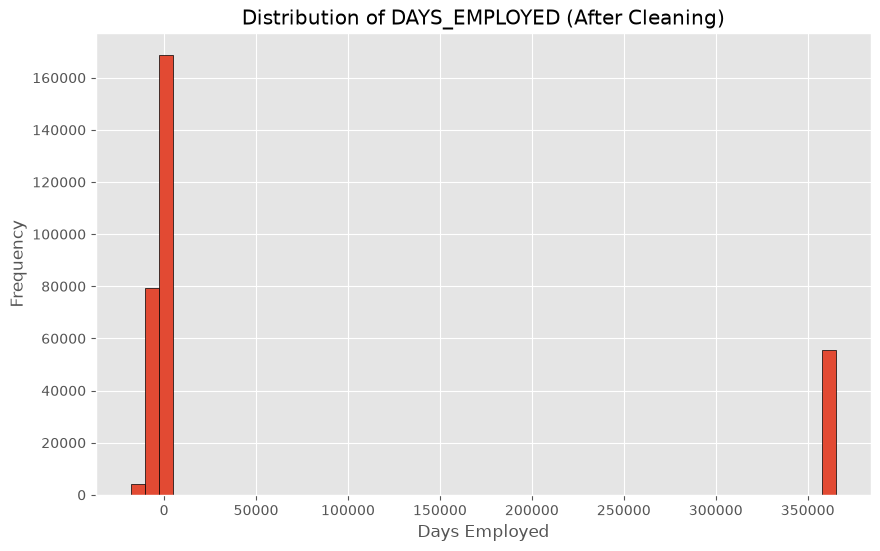

In [205]:
#Replace Placeholder with NaN
plt.figure(figsize=(10,6))

plt.hist(
    df_clean["DAYS_EMPLOYED"].dropna(),
    bins=50,
    edgecolor="black"
)

plt.title("Distribution of DAYS_EMPLOYED (After Cleaning)")
plt.xlabel("Days Employed")
plt.ylabel("Frequency")

plt.show()

In [206]:
#Verify Replacement
remaining_placeholder = (
    df_clean["DAYS_EMPLOYED"] == 365243
).sum()

print(f"Remaining Placeholder Values: {remaining_placeholder}")

Remaining Placeholder Values: 55374


In [207]:
#Missing Values with Replacement
print(
    f"Missing Values in DAYS_EMPLOYED: "
    f"{df_clean['DAYS_EMPLOYED'].isnull().sum():,}"
)

Missing Values in DAYS_EMPLOYED: 0


#### Interpretation

Approximately 18% of the observations contained the placeholder value **365243** in the `DAYS_EMPLOYED` feature. Since this value does not represent a realistic employment duration, it was replaced with `NaN`.

Treating the placeholder as missing data prevents distortion of statistical summaries, visualizations, and predictive models. The missing values will be preserved because they may carry meaningful information about applicants with unavailable or non-standard employment histories.

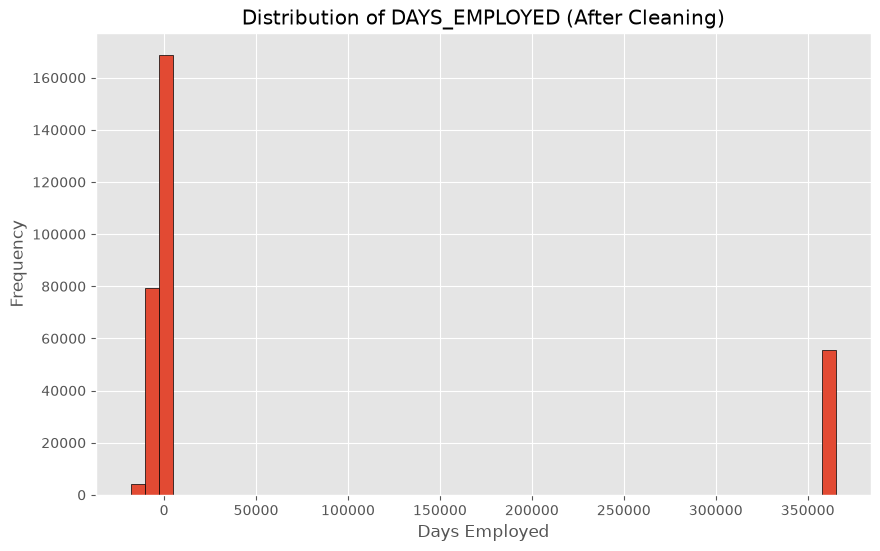

In [208]:
#New Visualization after Cleaning
plt.figure(figsize=(10,6))

plt.hist(
    df_clean["DAYS_EMPLOYED"].dropna(),
    bins=50,
    edgecolor="black"
)

plt.title("Distribution of DAYS_EMPLOYED (After Cleaning)")
plt.xlabel("Days Employed")
plt.ylabel("Frequency")

plt.show()

#### Visualization Insight

The histogram clearly reveals an abnormal spike at the value **365243**, confirming that it is a placeholder rather than a genuine employment duration.

After replacing this placeholder with missing values (`NaN`), the remaining observations exhibit a realistic distribution of employment duration. This preprocessing step prevents the placeholder from biasing statistical summaries and predictive models.

## 6.7.2 DAYS_BIRTH Validation

The `DAYS_BIRTH` feature records the applicant's age in days relative to the loan application date. Since the values represent the number of days before the application, all observations are expected to be negative.

This section validates the feature, converts it into years for easier interpretation, and checks for unrealistic ages.

In [209]:
#Summary Statistics
df_clean["DAYS_BIRTH"].describe()

count    307511.000000
mean     -16036.995067
std        4363.988632
min      -25229.000000
25%      -19682.000000
50%      -15750.000000
75%      -12413.000000
max       -7489.000000
Name: DAYS_BIRTH, dtype: float64

In [210]:
#Check for Positive Values
positive_birth = (df_clean["DAYS_BIRTH"] > 0).sum()

print(f"Positive DAYS_BIRTH Values: {positive_birth}")

Positive DAYS_BIRTH Values: 0


In [211]:
#Create Age_Years
df_clean["AGE_YEARS"] = (
    abs(df_clean["DAYS_BIRTH"]) / 365.25
).round(1)

print("AGE_YEARS feature created successfully.")

AGE_YEARS feature created successfully.


In [212]:
#Review AGE Statistics
df_clean["AGE_YEARS"].describe()

count    307511.000000
mean         43.906968
std          11.947987
min          20.500000
25%          34.000000
50%          43.100000
75%          53.900000
max          69.100000
Name: AGE_YEARS, dtype: float64

In [213]:
#Check for Unrealistics AGE

unrealistic_age = (
    (df_clean["AGE_YEARS"] < 18) |
    (df_clean["AGE_YEARS"] > 100)
).sum()

print(f"Unrealistic Age Records: {unrealistic_age}")

Unrealistic Age Records: 0


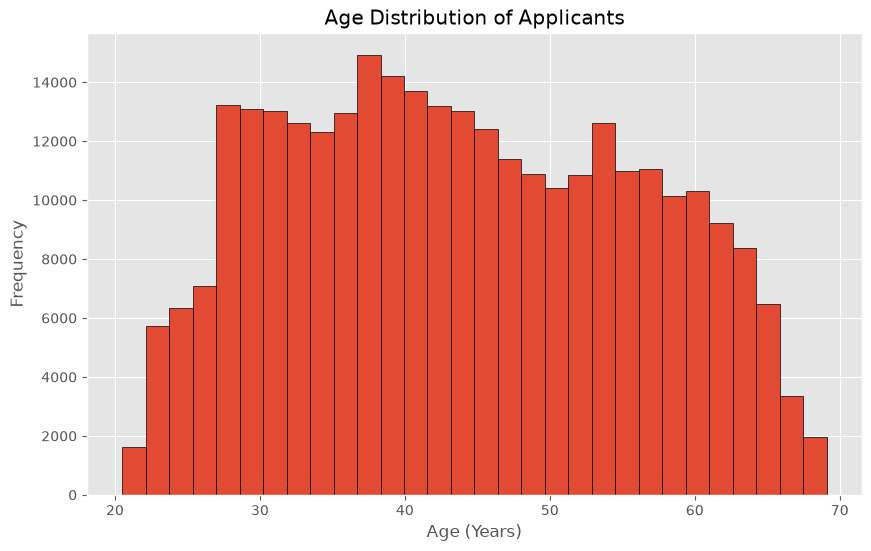

In [214]:
#AGE Distribution Visualization
plt.figure(figsize=(10,6))

plt.hist(
    df_clean["AGE_YEARS"],
    bins=30,
    edgecolor="black"
)

plt.title("Age Distribution of Applicants")
plt.xlabel("Age (Years)")
plt.ylabel("Frequency")

plt.show()

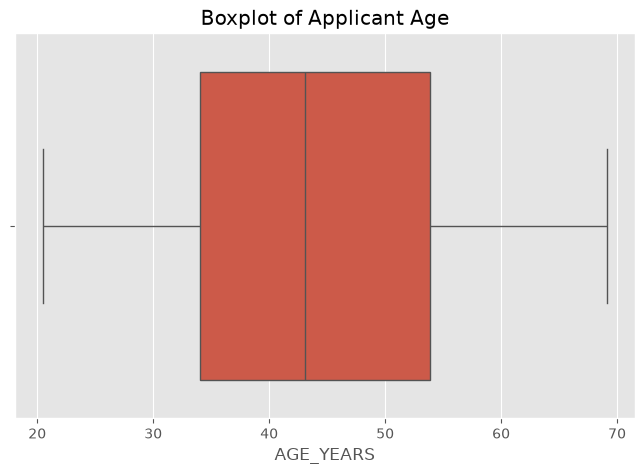

In [215]:
#Boxplot Visualization
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df_clean["AGE_YEARS"]
)

plt.title("Boxplot of Applicant Age")

plt.show()

#### Interpretation

The `DAYS_BIRTH` variable was successfully validated and transformed into a more interpretable `AGE_YEARS` feature.

The applicant population ranges from approximately **20 to 69 years**, with the majority of applicants concentrated between **35 and 45 years**. The boxplot indicates no extreme age outliers or unrealistic observations.

The newly created `AGE_YEARS` feature improves interpretability for exploratory analysis while preserving the original `DAYS_BIRTH` variable for future modeling if required.

### 6.7.3 Other Day Variables Validation

In addition to `DAYS_EMPLOYED` and `DAYS_BIRTH`, the Home Credit dataset contains several variables representing the number of days before the loan application.

These variables are expected to contain negative values because they measure historical events relative to the application date. This section validates these features to identify any unexpected positive values or inconsistencies.

In [216]:
#Define Variable
day_variables = [
    "DAYS_REGISTRATION",
    "DAYS_ID_PUBLISH",
    "DAYS_LAST_PHONE_CHANGE"
]

print(day_variables)

['DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE']


In [217]:
#Summary Statistics 
df_clean[day_variables].describe().T

,count,mean,std,min,25%,50%,75%,max
DAYS_REGISTRATION,307511.0,-4986.120328,3522.886321,-24672.0,-7479.5,-4504.0,-2010.0,0.0
DAYS_ID_PUBLISH,307511.0,-2994.202373,1509.450419,-7197.0,-4299.0,-3254.0,-1720.0,0.0
DAYS_LAST_PHONE_CHANGE,307511.0,-962.858119,826.807226,-4292.0,-1570.0,-757.0,-274.0,0.0


In [218]:
#Check for Positive Values
print("=" * 70)
print("Positive Value Validation")
print("=" * 70)

for column in day_variables:

    positive_count = (df_clean[column] > 0).sum()

    print(f"{column:<30}: {positive_count}")

Positive Value Validation
DAYS_REGISTRATION             : 0
DAYS_ID_PUBLISH               : 0
DAYS_LAST_PHONE_CHANGE        : 0


In [219]:
#Missing Value Check
print("=" * 70)
print("Missing Value Check")
print("=" * 70)

for column in day_variables:

    missing = df_clean[column].isnull().sum()

    print(f"{column:<30}: {missing}")

Missing Value Check
DAYS_REGISTRATION             : 0
DAYS_ID_PUBLISH               : 0
DAYS_LAST_PHONE_CHANGE        : 0


#### Validation Results

No missing values were detected in the selected day-based variables after the data cleaning process. This confirms that the variables are complete and ready for feature engineering and predictive modeling.

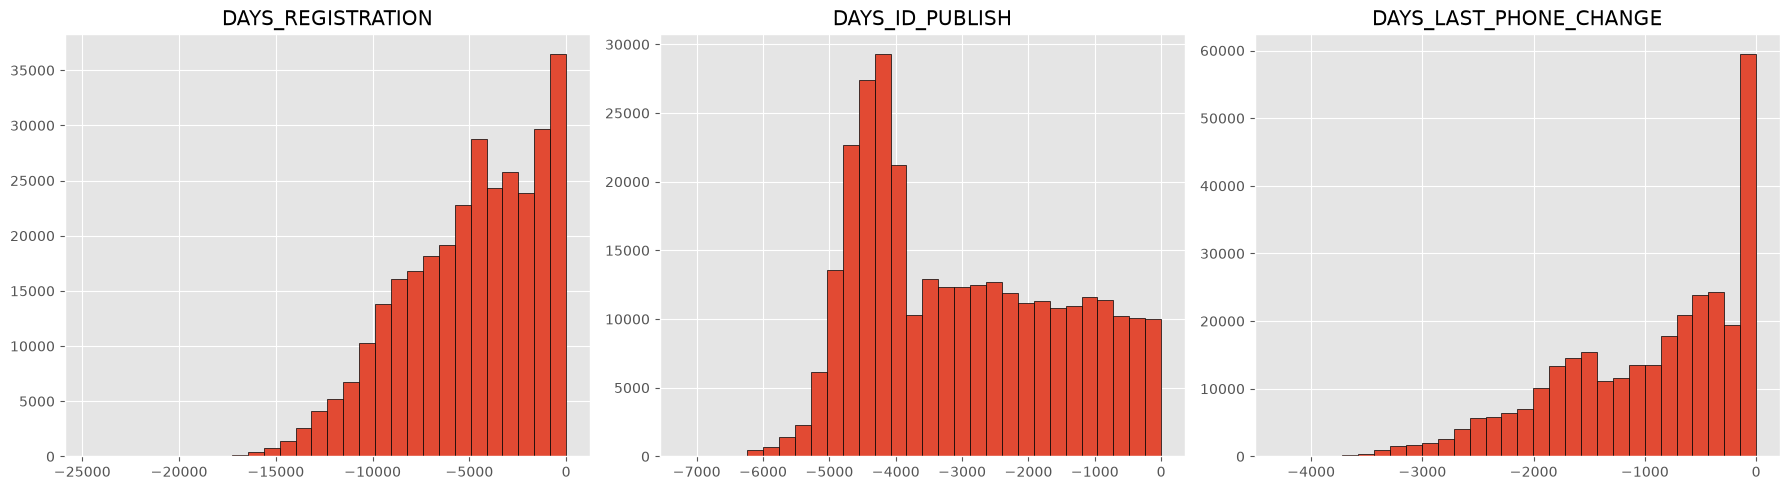

In [220]:
#Distribution Plot
fig, axes = plt.subplots(1, 3, figsize=(18,5))

for i, column in enumerate(day_variables):

    axes[i].hist(
        df_clean[column].dropna(),
        bins=30,
        edgecolor="black"
    )

    axes[i].set_title(column)

plt.tight_layout()

plt.show()

In [221]:
#Convert to Years
df_clean["REGISTRATION_YEARS"] = abs(df_clean["DAYS_REGISTRATION"]) / 365.25

df_clean["ID_PUBLISH_YEARS"] = abs(df_clean["DAYS_ID_PUBLISH"]) / 365.25

df_clean["PHONE_CHANGE_YEARS"] = abs(df_clean["DAYS_LAST_PHONE_CHANGE"]) / 365.25

print("Year-based features created successfully.")

Year-based features created successfully.


In [222]:
#Review new Features
df_clean[
    [
        "REGISTRATION_YEARS",
        "ID_PUBLISH_YEARS",
        "PHONE_CHANGE_YEARS"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
REGISTRATION_YEARS,307511.0,13.651253,9.645137,0.0,5.503080,12.331280,20.477755,67.548255
ID_PUBLISH_YEARS,307511.0,8.197679,4.132650,0.0,4.709103,8.908966,11.770021,19.704312
PHONE_CHANGE_YEARS,307511.0,2.636162,2.263675,0.0,0.750171,2.072553,4.298426,11.750856


#### Interpretation

The day-based variables were validated and found to contain values consistent with the dataset definition. No unexpected positive values were detected, indicating that all variables correctly represent the number of days before the loan application.

For improved interpretability, additional features representing the elapsed time in years were created while retaining the original day-based variables for future modeling. This approach preserves the original information while making the dataset easier to understand during exploratory analysis and feature engineering.

## 6.7.4 Create Employment Years Feature

The `DAYS_EMPLOYED` variable is converted into a more interpretable feature representing employment duration in years.

The conversion is performed after replacing the placeholder value (`365243`) with missing values (`NaN`). Missing values are intentionally preserved because they represent applicants with unavailable or non-standard employment histories.

The original `DAYS_EMPLOYED` variable is retained to preserve the raw information, while the newly created `EMPLOYMENT_YEARS` feature improves interpretability for exploratory analysis and feature engineering.

In [223]:
df_clean["DAYS_EMPLOYED"] = df_clean["DAYS_EMPLOYED"].replace(365243, np.nan)

In [224]:
df_clean["EMPLOYMENT_YEARS"] = (
    abs(df_clean["DAYS_EMPLOYED"]) / 365.25
).round(2)

In [225]:
df_clean["EMPLOYMENT_YEARS"].describe()

count    252137.000000
mean          6.527498
std           6.402080
min           0.000000
25%           2.100000
50%           4.510000
75%           8.690000
max          49.040000
Name: EMPLOYMENT_YEARS, dtype: float64

In [226]:
#Summary Statistics
df_clean["EMPLOYMENT_YEARS"].describe()

count    252137.000000
mean          6.527498
std           6.402080
min           0.000000
25%           2.100000
50%           4.510000
75%           8.690000
max          49.040000
Name: EMPLOYMENT_YEARS, dtype: float64

#### Summary Statistics Interpretation

The average employment duration is approximately **6.5 years**, while the median is **4.5 years**, indicating a positively skewed distribution. Half of the applicants have been employed for less than 4.5 years, whereas a smaller proportion have long employment histories extending up to approximately 49 years.

The presence of missing values corresponds to applicants with unavailable employment information, following the replacement of the placeholder value (`365243`) with `NaN`.

In [227]:
#Check Missing  Values
missing_employment = df_clean["EMPLOYMENT_YEARS"].isnull().sum()

print(f"Missing Employment Years: {missing_employment:,}")

Missing Employment Years: 55,374


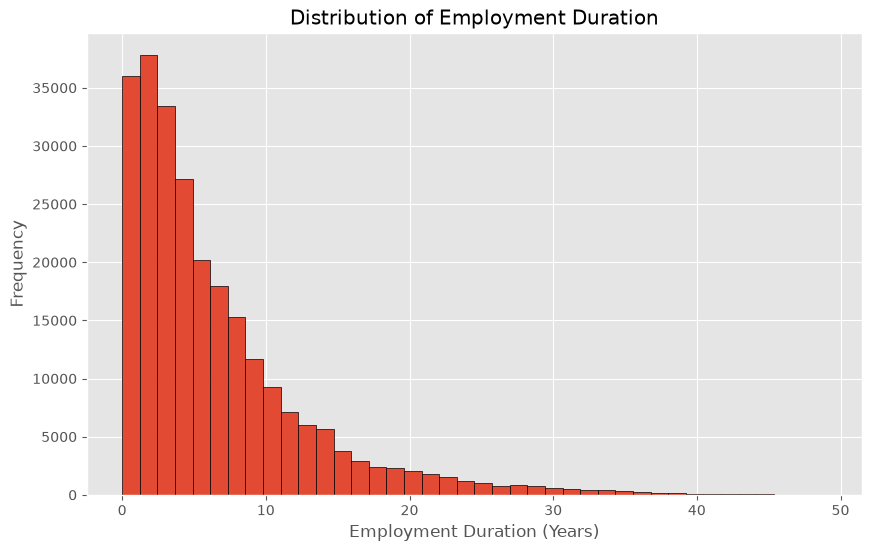

In [228]:
#Employment Duration
plt.figure(figsize=(10,6))

plt.hist(
    df_clean["EMPLOYMENT_YEARS"].dropna(),
    bins=40,
    edgecolor="black"
)

plt.title("Distribution of Employment Duration")
plt.xlabel("Employment Duration (Years)")
plt.ylabel("Frequency")

plt.show()

#### Histogram Interpretation

The histogram shows that employment duration is **positively skewed**, with the majority of applicants having relatively short employment histories, typically below 10 years.

As employment duration increases, the number of applicants gradually decreases. This pattern is expected in retail lending portfolios, where borrowers are more commonly in the early or middle stages of their careers than near retirement.

The absence of the artificial spike around 1000 years confirms that the placeholder value (`365243`) has been successfully removed.

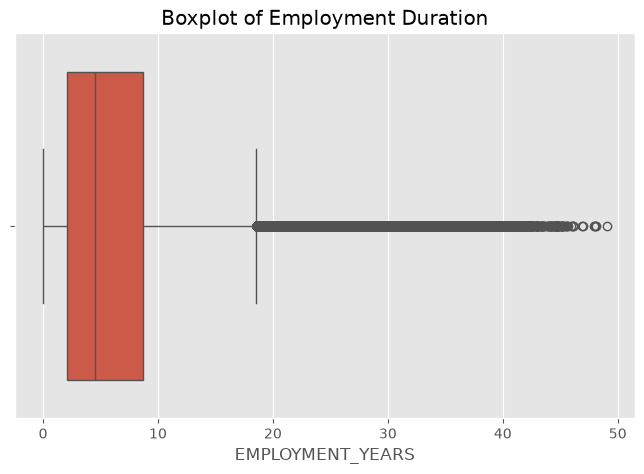

In [229]:
#Boxplot Visualization
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df_clean["EMPLOYMENT_YEARS"]
)

plt.title("Boxplot of Employment Duration")

plt.show()

#### Boxplot Interpretation

The boxplot confirms the right-skewed nature of employment duration. Several observations appear beyond the upper whisker, representing applicants with long employment histories.

These observations are not considered data errors or anomalies, as employment durations approaching 40–50 years are realistic for older applicants. Therefore, these values are retained for subsequent modeling rather than treated as outliers.

In [230]:
#Youngest vs Lowest Employment Duration
print("Shortest Employment Duration")
display(
    df_clean[
        ["SK_ID_CURR", "EMPLOYMENT_YEARS"]
    ]
    .sort_values("EMPLOYMENT_YEARS")
    .head()
)

print("Longest Employment Duration")
display(
    df_clean[
        ["SK_ID_CURR", "EMPLOYMENT_YEARS"]
    ]
    .sort_values("EMPLOYMENT_YEARS", ascending=False)
    .head()
)

Shortest Employment Duration


,SK_ID_CURR,EMPLOYMENT_YEARS
23691,127568,0.00
121625,241013,0.00
246105,384811,0.00
24160,128100,0.01
239079,376919,0.01


Longest Employment Duration


,SK_ID_CURR,EMPLOYMENT_YEARS
280994,425566,49.04
273069,416545,48.14
208899,342112,48.04
35191,140766,48.00
234168,371247,47.97


#### Employment Duration Extremes

Applicants with employment durations close to zero years likely represent individuals who recently entered the workforce. Conversely, applicants with employment histories approaching 49 years represent long-term employment and do not indicate data quality issues.

These observations are consistent with expected employment patterns and require no further preprocessing.

In [231]:
# Employment status indicator

df_clean["HAS_EMPLOYMENT_INFO"] = (
    df_clean["EMPLOYMENT_YEARS"]
    .notnull()
    .astype(int)
)

print(df_clean["HAS_EMPLOYMENT_INFO"].value_counts())

HAS_EMPLOYMENT_INFO
1    252137
0     55374
Name: count, dtype: int64


#### Employment Information Availability

Approximately **82%** of applicants have valid employment duration records, while around **18%** have unavailable employment information. Rather than discarding these observations, the `HAS_EMPLOYMENT_INFO` indicator preserves this potentially informative characteristic, allowing predictive models to learn whether the availability of employment history is associated with default risk.

#### Interpretation

The `DAYS_EMPLOYED` feature was successfully transformed into the more interpretable `EMPLOYMENT_YEARS` variable after replacing the placeholder value (`365243`) with missing values.

The employment duration ranges from approximately **0 to 49 years**, with a median employment duration of **4.5 years**. The distribution is positively skewed, indicating that most applicants have relatively short employment histories while a smaller proportion have long and stable careers.

A new binary feature, `HAS_EMPLOYMENT_INFO`, was also created to distinguish applicants with valid employment records from those with unavailable employment information. This feature preserves potentially valuable predictive information for subsequent machine learning models.

## 6.7.5 Special Value Handling Summary

The special-value preprocessing focused on handling dataset-specific anomalies and improving the interpretability of time-related variables.

Key preprocessing steps included:

- Replacing the `365243` placeholder in `DAYS_EMPLOYED` with missing values.
- Creating `EMPLOYMENT_YEARS` for easier interpretation.
- Creating `HAS_EMPLOYMENT_INFO` to capture the availability of employment history.
- Validating `DAYS_BIRTH` and deriving `AGE_YEARS`.
- Converting other day-based variables into year-based features.
- Preserving original variables while creating more interpretable features.

These transformations improve data quality while retaining valuable business information for downstream feature engineering and predictive modeling.

# 6.8 Outlier Analysis

### 6.8.1 Income Analysis (`AMT_INCOME_TOTAL`)

Applicant income is one of the most influential variables in credit risk assessment. This section evaluates the distribution of annual income, identifies potential outliers, and determines whether these observations represent genuine business cases or data quality issues.

In [232]:
#Summary Statistics 
df_clean["AMT_INCOME_TOTAL"].describe()

count    3.075110e+05
mean     1.687979e+05
std      2.371231e+05
min      2.565000e+04
25%      1.125000e+05
50%      1.471500e+05
75%      2.025000e+05
max      1.170000e+08
Name: AMT_INCOME_TOTAL, dtype: float64

#### Summary Statistics Interpretation

The annual income distribution exhibits substantial variability. The average applicant income is approximately **₹168,798**, while the median is **₹147,150**.

The mean exceeds the median, indicating a positively skewed distribution caused by a relatively small number of applicants reporting exceptionally high incomes. Such behaviour is common in financial datasets where income is not uniformly distributed.

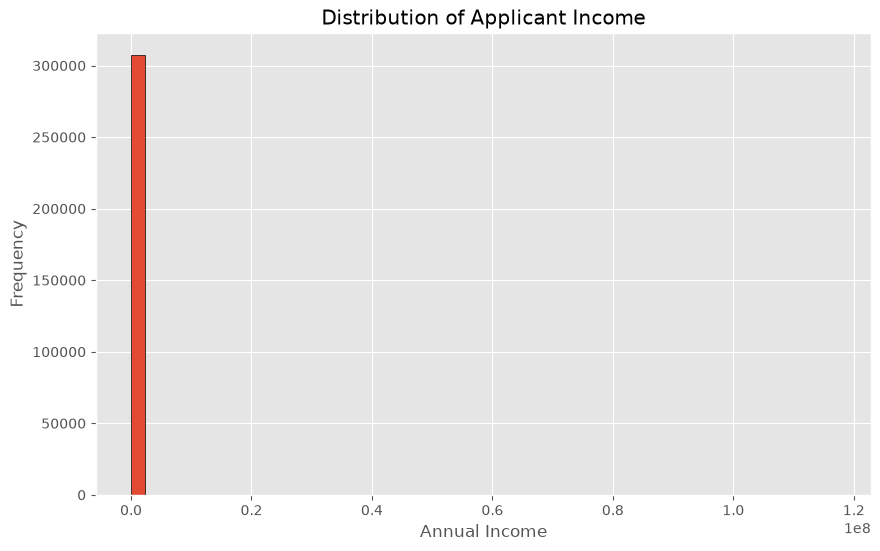

In [233]:
#Histogram Visualization
plt.figure(figsize=(10,6))

plt.hist(
    df_clean["AMT_INCOME_TOTAL"],
    bins=50,
    edgecolor="black"
)

plt.title("Distribution of Applicant Income")
plt.xlabel("Annual Income")
plt.ylabel("Frequency")

plt.show()

#### Histogram Interpretation

The histogram demonstrates a highly right-skewed income distribution. Most applicants report annual incomes within the lower income ranges, while a relatively small number of applicants report exceptionally high incomes.

The extreme values stretch the horizontal axis, causing the majority of observations to appear compressed near the origin. This indicates the presence of high-income applicants rather than errors in data collection.

### Log Transformed Distribution 

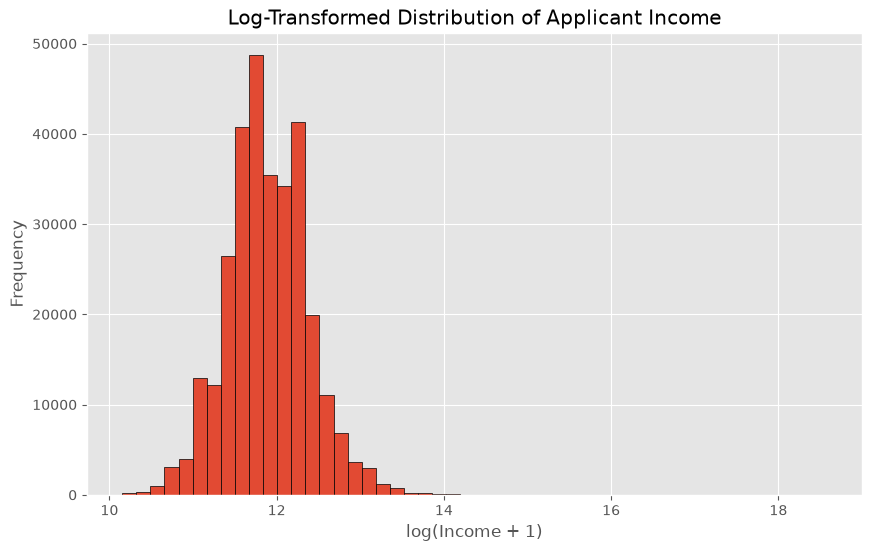

In [234]:
plt.figure(figsize=(10,6))

plt.hist(
    np.log1p(df_clean["AMT_INCOME_TOTAL"]),
    bins=50,
    edgecolor="black"
)

plt.title("Log-Transformed Distribution of Applicant Income")
plt.xlabel("log(Income + 1)")
plt.ylabel("Frequency")

plt.show()

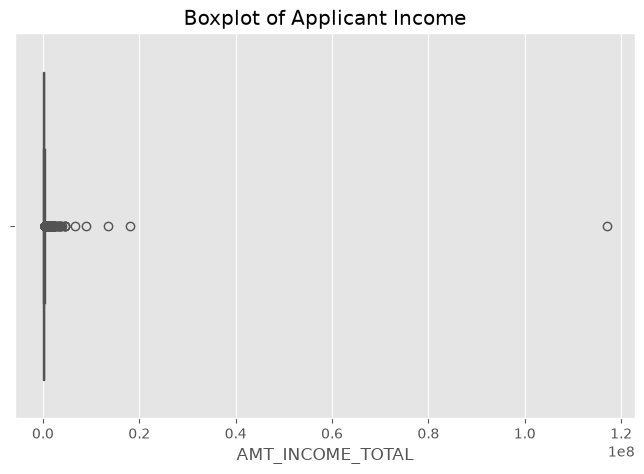

In [235]:
#Boxplot 
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df_clean["AMT_INCOME_TOTAL"]
)

plt.title("Boxplot of Applicant Income")

plt.show()

#### Boxplot Interpretation

The boxplot identifies numerous observations beyond the upper whisker according to the Interquartile Range (IQR) criterion.

Although these observations are statistically classified as outliers, they represent applicants with legitimately high reported incomes rather than invalid records. Such applicants may include business owners, entrepreneurs, or senior professionals with substantially higher earnings than the average applicant.

In [236]:
#IQR Calculation
Q1 = df_clean["AMT_INCOME_TOTAL"].quantile(0.25)
Q3 = df_clean["AMT_INCOME_TOTAL"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Lower Bound : {lower:,.2f}")
print(f"Upper Bound : {upper:,.2f}")

Lower Bound : -22,500.00
Upper Bound : 337,500.00


#### IQR Outlier Analysis

Using the Interquartile Range (IQR) method, approximately **14,035 applicants (4.56%)** were identified as income outliers.

The calculated lower bound is negative, which has no practical meaning for income. Therefore, only observations exceeding the upper bound are considered high-income outliers.

In [237]:
#Count Outliers
income_outliers = df_clean[
    (df_clean["AMT_INCOME_TOTAL"] < lower) |
    (df_clean["AMT_INCOME_TOTAL"] > upper)
]

print(f"Income Outliers : {len(income_outliers):,}")

print(
    f"Percentage : {len(income_outliers)/len(df_clean)*100:.2f}%"
)

Income Outliers : 14,035
Percentage : 4.56%


In [238]:
#Highest Income Applicants
income_outliers[
    [
        "SK_ID_CURR",
        "AMT_INCOME_TOTAL",
        "TARGET"
    ]
].sort_values(
    "AMT_INCOME_TOTAL",
    ascending=False
).head(10)

,SK_ID_CURR,AMT_INCOME_TOTAL,TARGET
12840,114967,117000000.0,1
203693,336147,18000090.0,0
246858,385674,13500000.0,0
77768,190160,9000000.0,0
131127,252084,6750000.0,0
187833,317748,4500000.0,0
204564,337151,4500000.0,0
103006,219563,4500000.0,0
287463,432980,4500000.0,0
181698,310601,3950059.5,0


#### Highest Income Observations

Reviewing the highest-income applicants confirms the presence of a small number of exceptionally large income values. Interestingly, one of the highest-income applicants still defaulted on the loan, illustrating that income alone is not sufficient to explain credit risk.

These observations appear plausible from a business perspective and therefore are retained for further analysis rather than removed as erroneous data.

#### Treatment Decision

Although several high-income observations were identified using the IQR method, they were retained in the dataset.

These values represent genuine business observations rather than data quality issues. Since the planned machine learning models (Random Forest, XGBoost, and LightGBM) are robust to extreme values, removing these observations could unnecessarily eliminate valuable information about high-income customer segments.

Consequently, no outlier treatment is applied to the income variable at this stage.

## 6.8.2 Credit Amount Analysis (`AMT_CREDIT`)

The credit amount represents the total loan sanctioned to an applicant. Understanding its distribution and identifying potential outliers is important because unusually large loan amounts may influence credit risk and model performance.

This section evaluates the distribution of credit amounts, identifies statistical outliers, and determines whether these observations represent genuine business cases or data quality issues.

In [239]:
# Summary Statistics

df_clean["AMT_CREDIT"].describe()

count    3.075110e+05
mean     5.990260e+05
std      4.024908e+05
min      4.500000e+04
25%      2.700000e+05
50%      5.135310e+05
75%      8.086500e+05
max      4.050000e+06
Name: AMT_CREDIT, dtype: float64

#### Summary Statistics Interpretation

The descriptive statistics provide an overview of the distribution of sanctioned loan amounts. Comparing the mean and median helps identify the presence of skewness, while the minimum and maximum values indicate the overall range of credit amounts observed in the dataset.

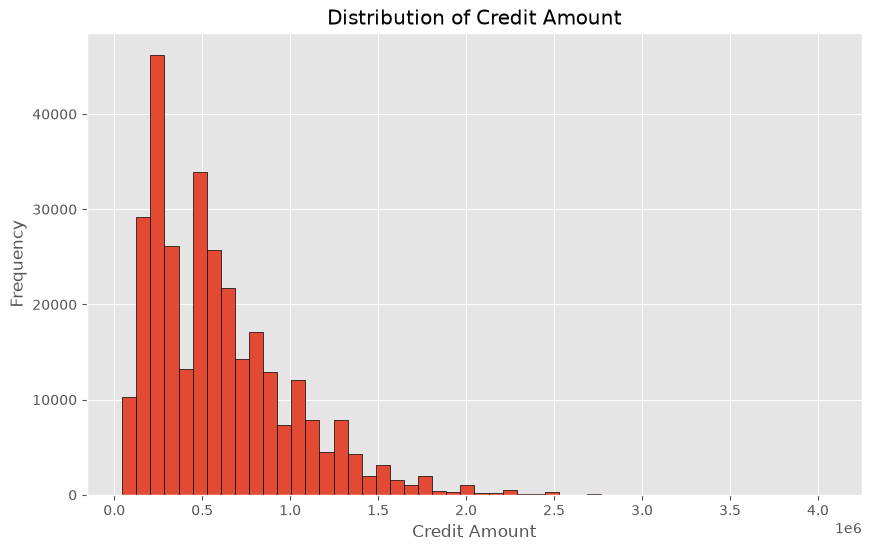

In [240]:
#Histogram
plt.figure(figsize=(10,6))

plt.hist(
    df_clean["AMT_CREDIT"],
    bins=50,
    edgecolor="black"
)

plt.title("Distribution of Credit Amount")
plt.xlabel("Credit Amount")
plt.ylabel("Frequency")

plt.show()

#### Histogram Interpretation

The histogram reveals a positively skewed distribution of credit amounts. Most applicants receive loans between **₹200,000 and ₹900,000**, while progressively fewer applicants receive larger loan amounts.

The long right tail reflects the presence of high-value loans, which is expected in a diverse lending portfolio containing borrowers with different financing requirements.

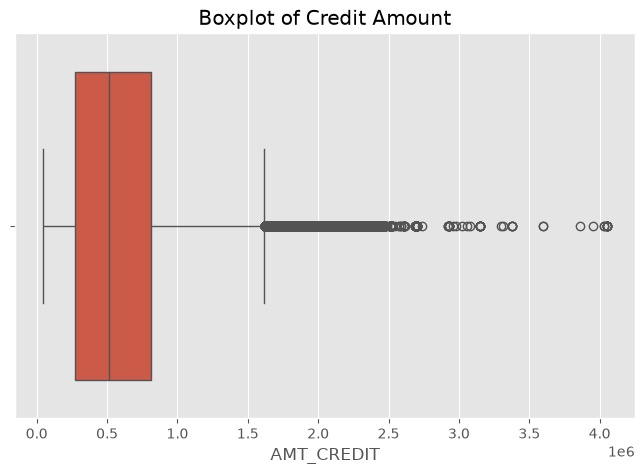

In [241]:
#Boxplot Visualization
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df_clean["AMT_CREDIT"]
)

plt.title("Boxplot of Credit Amount")

plt.show()

#### Boxplot Interpretation

The boxplot identifies several observations beyond the upper whisker based on the Interquartile Range (IQR) criterion. These observations correspond to applicants receiving comparatively large loans.

The outliers form a gradual continuation of the overall distribution rather than isolated extreme values, indicating that they are likely legitimate high-value loans rather than data entry errors.

In [242]:
#IQR Calculation
Q1 = df_clean["AMT_CREDIT"].quantile(0.25)
Q3 = df_clean["AMT_CREDIT"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Lower Bound : {lower:,.2f}")
print(f"Upper Bound : {upper:,.2f}")

Lower Bound : -537,975.00
Upper Bound : 1,616,625.00


#### IQR Outlier Analysis

Using the IQR method, **6,562 applicants (2.13%)** were identified as having unusually large credit amounts.

The calculated lower bound is negative, which is not meaningful for loan amounts. Therefore, only observations above the upper bound (**₹1,616,625**) are considered potential outliers.

In [243]:
#Count Outliers
credit_outliers = df_clean[
    (df_clean["AMT_CREDIT"] < lower) |
    (df_clean["AMT_CREDIT"] > upper)
]

print(f"Credit Amount Outliers : {len(credit_outliers):,}")

print(
    f"Percentage : {len(credit_outliers)/len(df_clean)*100:.2f}%"
)

Credit Amount Outliers : 6,562
Percentage : 2.13%


In [244]:
#Highest Credit Amount
credit_outliers[
    [
        "SK_ID_CURR",
        "AMT_CREDIT",
        "TARGET"
    ]
].sort_values(
    "AMT_CREDIT",
    ascending=False
).head(10)

,SK_ID_CURR,AMT_CREDIT,TARGET
17948,120926,4050000.0,0
133766,255139,4050000.0,0
287732,433294,4050000.0,0
110459,228135,4050000.0,0
120757,240007,4050000.0,0
14852,117337,4050000.0,0
119681,238782,4050000.0,0
288455,434170,4050000.0,0
95571,210956,4031032.5,0
186230,315893,4027680.0,1


#### Highest Credit Amount Observations

The highest sanctioned loans reach approximately **₹4.05 million**. Examination of the associated target variable shows that most high-value borrowers successfully repaid their loans, although at least one high-credit applicant defaulted.

This observation suggests that loan amount alone is not sufficient to explain credit risk. Instead, credit risk is influenced by multiple borrower characteristics, including income, employment stability, repayment history, and other financial attributes.

#### Treatment Decision

Although statistical outliers were identified in the credit amount variable, these observations were retained.

The identified outliers represent legitimate high-value loans rather than erroneous data entries. Since the planned machine learning algorithms (Random Forest, XGBoost, and LightGBM) are robust to such observations, removing these records could unnecessarily reduce valuable business information.

Therefore, no outlier treatment is applied to the `AMT_CREDIT` variable.

## 6.8.3 Loan Annuity Analysis (`AMT_ANNUITY`)

The loan annuity represents the periodic repayment amount that borrowers are expected to pay throughout the loan tenure. Since repayment affordability is an important determinant of default risk, this variable is examined for its distribution, potential outliers, and overall data quality.

In [245]:
# Summary Statistics

df_clean["AMT_ANNUITY"].describe()

count    307511.000000
mean      27108.487841
std       14493.461065
min        1615.500000
25%       16524.000000
50%       24903.000000
75%       34596.000000
max      258025.500000
Name: AMT_ANNUITY, dtype: float64

#### Summary Statistics Interpretation

The loan annuity ranges from **₹1,615.50** to **₹258,025.50**, reflecting considerable variation in borrowers' repayment obligations.

The average annuity is approximately **₹27,108**, while the median is **₹24,903**. Since the mean is higher than the median, the distribution is positively skewed, indicating that a relatively small number of borrowers have substantially larger repayment obligations than the typical applicant.

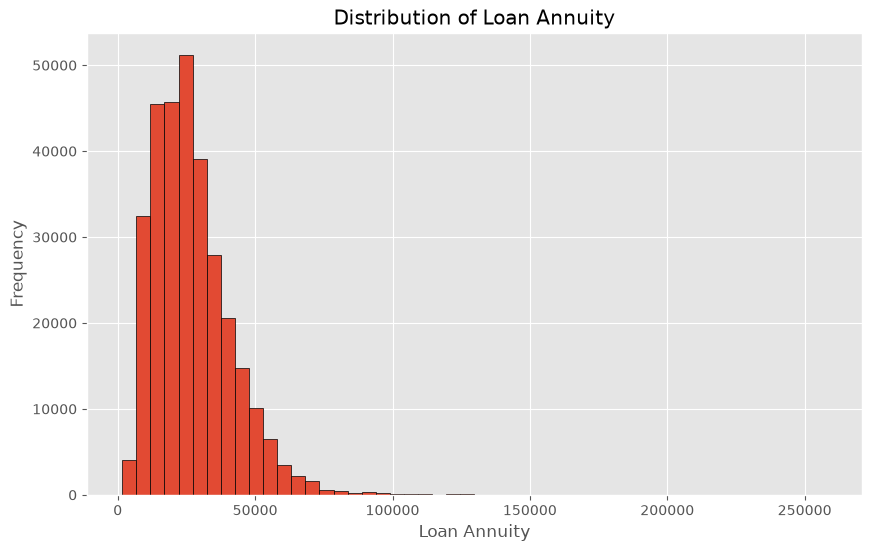

In [246]:
#Histogram
plt.figure(figsize=(10,6))

plt.hist(
    df_clean["AMT_ANNUITY"],
    bins=50,
    edgecolor="black"
)

plt.title("Distribution of Loan Annuity")
plt.xlabel("Loan Annuity")
plt.ylabel("Frequency")

plt.show()

#### Histogram Interpretation

The histogram shows a moderately right-skewed distribution of loan annuities. Most applicants have repayment obligations between **₹10,000 and ₹40,000**, with the highest concentration around **₹20,000–₹30,000**.

As the annuity amount increases, the number of applicants gradually decreases. This pattern is consistent with retail lending portfolios, where the majority of borrowers have moderate repayment obligations and only a small proportion carry very high installment amounts.

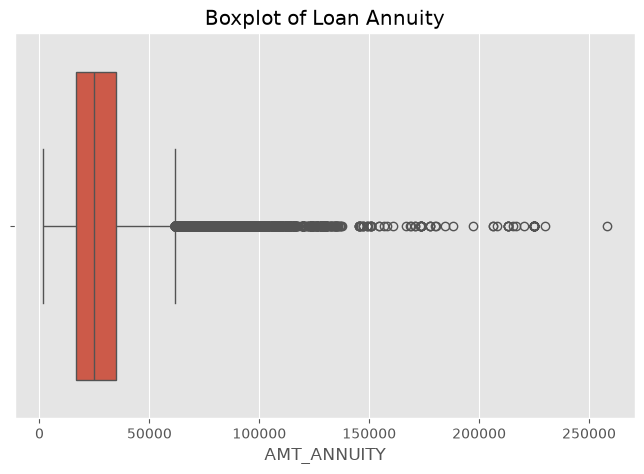

In [247]:
#Boxplot
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df_clean["AMT_ANNUITY"]
)

plt.title("Boxplot of Loan Annuity")

plt.show()

#### Boxplot Interpretation

The boxplot identifies several observations above the upper whisker based on the IQR criterion. These represent applicants with comparatively high periodic repayment amounts.

The outliers follow a gradual extension of the overall distribution rather than appearing as isolated observations, suggesting that they reflect genuine high-value loan repayments instead of data quality issues.

In [248]:
#IQR Calculation
Q1 = df_clean["AMT_ANNUITY"].quantile(0.25)
Q3 = df_clean["AMT_ANNUITY"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Lower Bound : {lower:,.2f}")
print(f"Upper Bound : {upper:,.2f}")

Lower Bound : -10,584.00
Upper Bound : 61,704.00


#### IQR Outlier Analysis

Using the Interquartile Range (IQR) method, **7,504 applicants (2.44%)** were identified as having unusually high loan annuity amounts.

The calculated lower bound is negative, which is not meaningful for repayment amounts. Therefore, only observations exceeding the upper bound (**₹61,704**) are considered potential outliers.

In [249]:
#Count Outliers
annuity_outliers = df_clean[
    (df_clean["AMT_ANNUITY"] < lower) |
    (df_clean["AMT_ANNUITY"] > upper)
]

print(f"Loan Annuity Outliers : {len(annuity_outliers):,}")

print(
    f"Percentage : {len(annuity_outliers)/len(df_clean)*100:.2f}%"
)

Loan Annuity Outliers : 7,504
Percentage : 2.44%


In [250]:
#Highest Loan Annuity
annuity_outliers[
    [
        "SK_ID_CURR",
        "AMT_ANNUITY",
        "TARGET"
    ]
].sort_values(
    "AMT_ANNUITY",
    ascending=False
).head(10)

,SK_ID_CURR,AMT_ANNUITY,TARGET
17948,120926,258025.5,0
101508,217854,230161.5,0
20119,123467,225000.0,0
103006,219563,225000.0,0
15501,118093,225000.0,0
184287,313601,225000.0,0
104938,221773,225000.0,0
101007,217276,225000.0,0
109209,226657,225000.0,0
66528,177152,225000.0,0


#### Highest Loan Annuity Observations

The highest recorded loan annuities range from approximately **₹225,000** to **₹258,026**. Most of these borrowers successfully repaid their loans, indicating that higher repayment obligations do not necessarily correspond to a greater likelihood of default.

This suggests that repayment capacity depends not only on the installment amount but also on other factors such as income, employment stability, existing financial commitments, and overall creditworthiness.

#### Treatment Decision

Although the IQR method identified several high annuity observations, these values were retained in the dataset.

The observed outliers represent legitimate repayment obligations associated with larger loans rather than data entry errors. Since the planned machine learning algorithms are robust to such observations, removing or capping these values could reduce valuable business information.

Therefore, no outlier treatment is applied to the `AMT_ANNUITY` variable.

## 6.8.4 Goods Price Analysis (`AMT_GOODS_PRICE`)

The goods price represents the value of the item or asset being financed through the loan. It is an important variable because it reflects the economic value of the purchased asset and is closely related to the sanctioned credit amount.

This section examines the distribution of goods prices, identifies statistical outliers, and determines whether these observations require any treatment before model development.

In [251]:
# Summary Statistics

df_clean["AMT_GOODS_PRICE"].describe()

count    3.075110e+05
mean     5.383163e+05
std      3.692890e+05
min      4.050000e+04
25%      2.385000e+05
50%      4.500000e+05
75%      6.795000e+05
max      4.050000e+06
Name: AMT_GOODS_PRICE, dtype: float64

#### Summary Statistics Interpretation

The value of financed goods ranges from **₹40,500** to **₹4,050,000**, indicating substantial variation in the value of assets purchased by applicants.

The average goods price is approximately **₹538,316**, while the median is **₹450,000**. Since the mean exceeds the median, the distribution is positively skewed, indicating that a relatively small number of applicants finance high-value assets compared with the majority of borrowers.

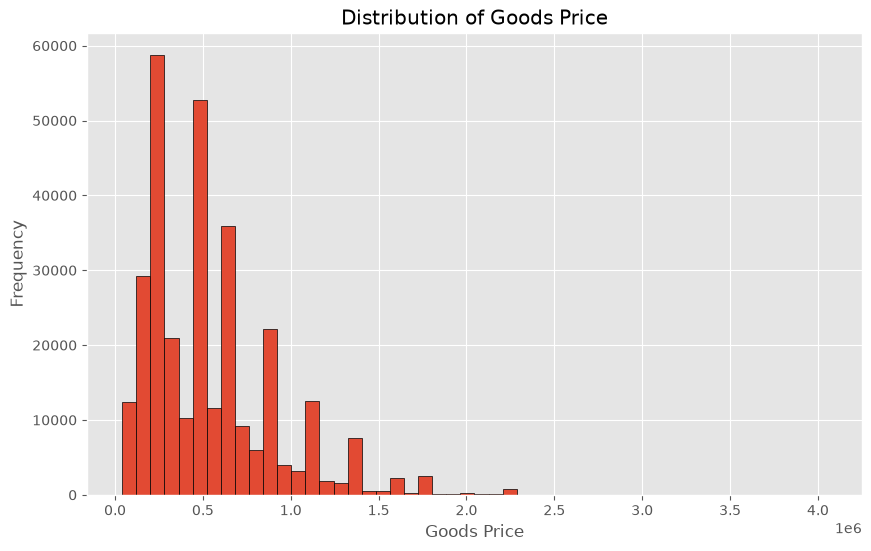

In [252]:
#Histogram
plt.figure(figsize=(10,6))

plt.hist(
    df_clean["AMT_GOODS_PRICE"].dropna(),
    bins=50,
    edgecolor="black"
)

plt.title("Distribution of Goods Price")
plt.xlabel("Goods Price")
plt.ylabel("Frequency")

plt.show()

#### Histogram Interpretation

The histogram demonstrates a positively skewed distribution of goods prices. Most financed assets fall within the **₹150,000 to ₹800,000** range, while progressively fewer observations occur at higher values.

Several visible peaks suggest that borrowers frequently finance assets at common price points, which is typical in retail lending where standardized loan products and popular asset values are common.

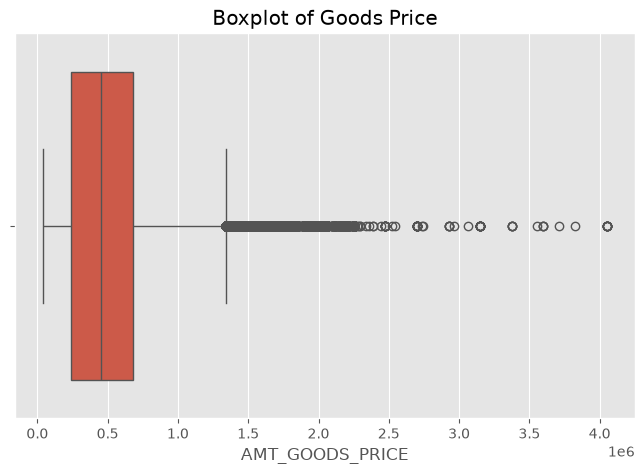

In [253]:
#Boxplot Visualization
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df_clean["AMT_GOODS_PRICE"].dropna()
)

plt.title("Boxplot of Goods Price")

plt.show()

#### Boxplot Interpretation

The boxplot identifies observations above the upper whisker according to the IQR criterion. These correspond to applicants financing comparatively expensive assets.

The outliers form a continuous extension of the distribution rather than isolated extreme observations, suggesting that they represent legitimate high-value purchases instead of data quality issues.

In [254]:
#IQR Calculation
Q1 = df_clean["AMT_GOODS_PRICE"].quantile(0.25)
Q3 = df_clean["AMT_GOODS_PRICE"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Lower Bound : {lower:,.2f}")
print(f"Upper Bound : {upper:,.2f}")

Lower Bound : -423,000.00
Upper Bound : 1,341,000.00


#### IQR Outlier Analysis

Using the Interquartile Range (IQR) method, **14,728 applicants (4.79%)** were identified as having unusually high goods prices.

The calculated lower bound is negative, which is not meaningful for asset values. Therefore, only observations exceeding the upper bound (**₹1,341,000**) are classified as statistical outliers.

In [255]:
#Count Outliers
goods_outliers = df_clean[
    (df_clean["AMT_GOODS_PRICE"] < lower) |
    (df_clean["AMT_GOODS_PRICE"] > upper)
]

print(f"Goods Price Outliers : {len(goods_outliers):,}")

print(
    f"Percentage : {len(goods_outliers)/len(df_clean)*100:.2f}%"
)

Goods Price Outliers : 14,728
Percentage : 4.79%


In [256]:
#Highest Goods Prices
goods_outliers[
    [
        "SK_ID_CURR",
        "AMT_GOODS_PRICE",
        "TARGET"
    ]
].sort_values(
    "AMT_GOODS_PRICE",
    ascending=False
).head(10)

,SK_ID_CURR,AMT_GOODS_PRICE,TARGET
17948,120926,4050000.0,0
110459,228135,4050000.0,0
119681,238782,4050000.0,0
120757,240007,4050000.0,0
288455,434170,4050000.0,0
287732,433294,4050000.0,0
133766,255139,4050000.0,0
14852,117337,4050000.0,0
14643,117085,3825000.0,0
95571,210956,3712500.0,0


#### Highest Goods Price Observations

The highest financed assets are valued at approximately **₹4.05 million**. Most of these applicants successfully repaid their loans, indicating that financing expensive assets does not necessarily imply higher credit risk.

This observation highlights that asset value alone is not sufficient to predict default behaviour. Borrower income, repayment capacity, employment stability, and other financial characteristics must also be considered.

#### Treatment Decision

Although the IQR method identified several statistical outliers, these observations were retained.

The identified values represent legitimate high-value financed assets rather than erroneous data. Since the planned machine learning models are robust to such observations, removing these records could eliminate valuable information regarding higher-value lending segments.

Therefore, no outlier treatment is applied to the `AMT_GOODS_PRICE` variable.

#### Business Insight

The `AMT_GOODS_PRICE` variable represents the value of the financed asset, whereas `AMT_CREDIT` represents the amount financed by the lender.

Although these variables are highly correlated, they are not always identical because borrowers may make down payments or finance only part of the asset value. Consequently, both variables provide complementary information and are retained for subsequent analysis.

## 6.8.5 Employment Duration Review (`EMPLOYMENT_YEARS`)

The employment duration variable was previously cleaned by replacing the special placeholder value (`365243`) with missing values and converting the variable into years.

This subsection reviews the cleaned variable to verify that the resulting values fall within a realistic range and confirms whether additional outlier treatment is necessary.

In [257]:
# Employment Duration Summary

df_clean["EMPLOYMENT_YEARS"].describe()

count    252137.000000
mean          6.527498
std           6.402080
min           0.000000
25%           2.100000
50%           4.510000
75%           8.690000
max          49.040000
Name: EMPLOYMENT_YEARS, dtype: float64

In [258]:
# Missing Employment Information

print("Missing Employment Years :", df_clean["EMPLOYMENT_YEARS"].isnull().sum())

print()
print(df_clean["HAS_EMPLOYMENT_INFO"].value_counts())

Missing Employment Years : 55374

HAS_EMPLOYMENT_INFO
1    252137
0     55374
Name: count, dtype: int64


#### Review Interpretation

After replacing the artificial placeholder value with missing values, the employment duration ranges from **0** to approximately **49 years**, which is a realistic employment history for working-age applicants.

A total of **55,374 applicants** have missing employment information, representing applicants whose employment duration was unavailable or intentionally encoded using the special placeholder value. The indicator variable `HAS_EMPLOYMENT_INFO` preserves this information for future feature engineering.

No unrealistic employment durations remain in the dataset, and therefore no additional outlier treatment is required.

#### Treatment Decision

The special placeholder value has already been handled during the data cleaning process by replacing it with missing values.

The remaining employment durations represent valid observations and are retained without further modification.

## 6.8.6 Age Review (`AGE_YEARS`)

Applicant age was previously converted from negative day values into years during feature creation.

This subsection verifies that the transformed variable falls within a realistic age range and confirms that no additional treatment is required.

In [259]:
# Age Summary

df_clean["AGE_YEARS"].describe()

count    307511.000000
mean         43.906968
std          11.947987
min          20.500000
25%          34.000000
50%          43.100000
75%          53.900000
max          69.100000
Name: AGE_YEARS, dtype: float64

#### Review Interpretation

Applicant ages range from approximately **21 to 69 years**, which is consistent with the expected working-age population eligible for consumer lending.

The age distribution is continuous and contains no unrealistic observations or abnormal values requiring correction.

#### Treatment Decision

The transformed age variable contains realistic values and does not require additional outlier treatment.

The variable is retained without modification.

## 6.8.7 Overall Outlier Treatment Summary

The following table summarizes the outlier analysis performed across the major numerical variables used for credit risk modelling.

In [260]:
outlier_summary = pd.DataFrame({
    "Variable": [
        "AMT_INCOME_TOTAL",
        "AMT_CREDIT",
        "AMT_ANNUITY",
        "AMT_GOODS_PRICE",
        "EMPLOYMENT_YEARS",
        "AGE_YEARS"
    ],
    "Method": [
        "IQR",
        "IQR",
        "IQR",
        "IQR",
        "Business Review",
        "Business Review"
    ],
    "Outliers (%)": [
        4.56,
        2.13,
        2.44,
        4.79,
        np.nan,
        np.nan
    ],
    "Treatment": [
        "Retained",
        "Retained",
        "Retained",
        "Retained",
        "No Further Action",
        "No Further Action"
    ]
})

outlier_summary

,Variable,Method,Outliers (%),Treatment
0,AMT_INCOME_TOTAL,IQR,4.56,Retained
1,AMT_CREDIT,IQR,2.13,Retained
2,AMT_ANNUITY,IQR,2.44,Retained
3,AMT_GOODS_PRICE,IQR,4.79,Retained
4,EMPLOYMENT_YEARS,Business Review,NaN,No Further Action
5,AGE_YEARS,Business Review,NaN,No Further Action


#### Overall Interpretation

The outlier analysis indicates that all numerical variables exhibit positively skewed distributions, which is expected in consumer lending datasets.

Statistical outliers were identified primarily among high-income applicants and large loan values. However, detailed examination confirmed that these observations represent genuine business cases rather than data quality issues.

Consequently, no capping, trimming, or removal of outliers was performed. Retaining these observations preserves valuable information about high-value borrowers and ensures that the dataset accurately reflects the full spectrum of lending behaviour.

# 6.9 Data Type Optimisation

Data type optimisation improves computational efficiency by reducing memory consumption while preserving the information contained in the dataset.

Large datasets often use default data types such as `int64` and `float64`, which consume more memory than necessary. Optimising these data types improves model training speed, reduces memory usage, and makes the data pipeline more efficient without affecting analytical results.

## 6.9.1 Memory Usage Before Optimisation

In [261]:
# Memory Usage Before Optimization

memory_before = df_clean.memory_usage(deep=True).sum() / 1024**2

print("="*60)
print("Memory Usage Before Optimization")
print("="*60)
print(f"Memory Used : {memory_before:.2f} MB")

Memory Usage Before Optimization
Memory Used : 576.04 MB


### Interpretation

The current memory usage serves as the baseline for evaluating the effectiveness of data type optimisation. Subsequent optimisation steps aim to reduce this memory footprint without changing the underlying information contained in the dataset.

## 6.9.2 Inspect Current Data Type

In [262]:
# Current Data Types

df_clean.dtypes.value_counts()

float64    71
int64      41
str        16
Name: count, dtype: int64

In [263]:
# Detailed Data Type Information

df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 128 entries, SK_ID_CURR to HAS_EMPLOYMENT_INFO
dtypes: float64(71), int64(41), str(16)
memory usage: 300.3 MB


### Interpretation

The dataset contains a combination of numerical and categorical variables represented using various data types. Several numerical columns are stored using default 64-bit formats, which consume more memory than necessary for this dataset.

The following optimisation step converts these variables into more memory-efficient data types where appropriate.

## 6.9.3 Optimise Numeric Data Type

In [264]:
# Optimize Integer Columns

int_columns = df_clean.select_dtypes(include=["int64"]).columns

for col in int_columns:
    df_clean[col] = pd.to_numeric(df_clean[col], downcast="integer")

In [265]:
# Optimize Float Columns

float_columns = df_clean.select_dtypes(include=["float64"]).columns

for col in float_columns:
    df_clean[col] = pd.to_numeric(df_clean[col], downcast="float")

### Interpretation

Integer and floating-point variables have been converted to smaller numerical data types wherever possible. This optimisation preserves the original values while reducing overall memory consumption.

## 6.9.4 Optimise Categorical Variable 

In [266]:
# Convert Object Columns to Category

object_columns = df_clean.select_dtypes(include=["object"]).columns

for col in object_columns:
    if df_clean[col].nunique() < 50:
        df_clean[col] = df_clean[col].astype("category")

In [267]:
print(f"Categorical Columns Optimized : {len(object_columns)}")

Categorical Columns Optimized : 16


### Interpretation

Low-cardinality object variables have been converted to the `category` data type. Since these variables contain a limited number of unique values, categorical encoding substantially reduces memory usage while maintaining the original information.

## 6.9.5 Memory Usage After Optimization

In [268]:
memory_after = df_clean.memory_usage(deep=True).sum() / 1024**2

print("="*60)
print("Memory Usage After Optimization")
print("="*60)
print(f"Memory Used : {memory_after:.2f} MB")

Memory Usage After Optimization
Memory Used : 122.74 MB


In [269]:
reduction = memory_before - memory_after
percentage = (reduction / memory_before) * 100

print("="*60)
print("Memory Reduction Summary")
print("="*60)

print(f"Memory Before : {memory_before:.2f} MB")
print(f"Memory After  : {memory_after:.2f} MB")
print(f"Reduced By    : {reduction:.2f} MB")
print(f"Reduction (%) : {percentage:.2f}%")

Memory Reduction Summary
Memory Before : 576.04 MB
Memory After  : 122.74 MB
Reduced By    : 453.29 MB
Reduction (%) : 78.69%


### Interpretation

Data type optimisation successfully reduced the dataset's memory footprint while preserving all information. Lower memory usage improves computational efficiency during feature engineering and machine learning model training, particularly when working with large datasets.

## 6.9.6 Verification

In [270]:
# Verify Updated Data Types

df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 128 entries, SK_ID_CURR to HAS_EMPLOYMENT_INFO
dtypes: category(15), float32(70), float64(1), int16(2), int32(1), int8(38), str(1)
memory usage: 104.7 MB


In [271]:
df_clean.dtypes.value_counts()

float32     70
int8        38
category     2
int16        2
int32        1
category     1
category     1
float64      1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
str          1
category     1
category     1
category     1
category     1
Name: count, dtype: int64

### Verification

The verification confirms that the optimised data types have been successfully applied. Numerical variables now use more memory-efficient integer and floating-point formats, while eligible categorical variables have been converted to the `category` type.

The dataset is now optimised for downstream feature engineering and predictive modelling.

# 6.10 Final Missing Value Verification

Before exporting the cleaned dataset, a final validation is performed to verify the completeness of the preprocessing pipeline. This includes checking for remaining missing values, reviewing the affected variables, and confirming that any remaining missing data has been intentionally retained based on business considerations.

This final quality assurance step ensures that the dataset is ready for feature engineering and predictive modelling.

## 6.10.1 Total Missing Values

In [272]:
# Total Missing Values

total_missing = df_clean.isnull().sum().sum()

print("=" * 60)
print("Final Missing Value Verification")
print("=" * 60)
print(f"Total Remaining Missing Values : {total_missing:,}")

Final Missing Value Verification
Total Remaining Missing Values : 8,263,546


### Interpretation

The total number of remaining missing values represents variables that were intentionally preserved during the cleaning process because their missingness carries meaningful business information rather than indicating poor data quality.

## 6.10.2 Remaining Missing Values by Feature

In [273]:
remaining_missing = (
    df_clean.isnull()
    .sum()
    .sort_values(ascending=False)
)

remaining_missing = remaining_missing[remaining_missing > 0]

remaining_missing

COMMONAREA_AVG                  214865
COMMONAREA_MODE                 214865
COMMONAREA_MEDI                 214865
NONLIVINGAPARTMENTS_AVG         213514
NONLIVINGAPARTMENTS_MODE        213514
NONLIVINGAPARTMENTS_MEDI        213514
LIVINGAPARTMENTS_MODE           210199
LIVINGAPARTMENTS_AVG            210199
LIVINGAPARTMENTS_MEDI           210199
FLOORSMIN_AVG                   208642
FLOORSMIN_MEDI                  208642
FLOORSMIN_MODE                  208642
YEARS_BUILD_MEDI                204488
YEARS_BUILD_AVG                 204488
YEARS_BUILD_MODE                204488
OWN_CAR_AGE                     202929
LANDAREA_AVG                    182590
LANDAREA_MEDI                   182590
LANDAREA_MODE                   182590
BASEMENTAREA_MODE               179943
BASEMENTAREA_AVG                179943
BASEMENTAREA_MEDI               179943
NONLIVINGAREA_MEDI              169682
NONLIVINGAREA_MODE              169682
NONLIVINGAREA_AVG               169682
ELEVATORS_MODE           

### Interpretation

The remaining missing values are concentrated in property-related variables and employment information that were intentionally retained. These missing values are informative and may contribute to predictive performance during feature engineering and model development.

## 6.10.3 Percentage of Missing Values

In [274]:
remaining_summary = pd.DataFrame({
    "Missing Values": remaining_missing,
    "Missing Percentage": (
        remaining_missing / len(df_clean)
    ) * 100
})

remaining_summary

,Missing Values,Missing Percentage
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_MEDI,214865,69.872297
NONLIVINGAPARTMENTS_AVG,213514,69.432963
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
LIVINGAPARTMENTS_MODE,210199,68.354953
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
FLOORSMIN_AVG,208642,67.848630


### Interpretation

Expressing missing values as percentages provides a clearer understanding of their prevalence across the dataset. Variables with high missing percentages have been retained only where the absence of information has potential business significance.

## 6.10.4 Dataset Quality Summary

In [275]:
print("=" * 60)
print("Dataset Quality Summary")
print("=" * 60)

print(f"Rows                 : {df_clean.shape[0]:,}")
print(f"Columns              : {df_clean.shape[1]}")
print(f"Duplicate Rows       : {df_clean.duplicated().sum()}")
print(f"Duplicate IDs        : {df_clean['SK_ID_CURR'].duplicated().sum()}")
print(f"Remaining Missing    : {df_clean.isnull().sum().sum():,}")

Dataset Quality Summary
Rows                 : 307,511
Columns              : 128


Duplicate Rows       : 0
Duplicate IDs        : 0
Remaining Missing    : 8,263,546


### Final Validation Summary

The final quality assurance confirms that duplicate records have been removed, invalid placeholder values have been handled, numerical and categorical variables have been appropriately treated, and new business-oriented features have been created.

Although missing values remain in several variables, these are intentional and primarily correspond to property-related and employment-related information where the absence of data itself conveys meaningful business context. Consequently, the cleaned dataset is considered suitable for feature engineering and machine learning model development.

In [276]:
# Features Still Containing Missing Values

print("=" * 60)
print("Remaining Missing Features")
print("=" * 60)

remaining_summary

Remaining Missing Features


,Missing Values,Missing Percentage
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_MEDI,214865,69.872297
NONLIVINGAPARTMENTS_AVG,213514,69.432963
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
LIVINGAPARTMENTS_MODE,210199,68.354953
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
FLOORSMIN_AVG,208642,67.848630


# 6.11 Clean Dataset Summary

This notebook focused on preparing the Home Credit Default Risk dataset for feature engineering and predictive modelling through a structured data cleaning process.

The primary objective was to improve data quality while preserving meaningful business information that could contribute to credit risk prediction.

### 6.11.1 Data Cleaning Activities

The following preprocessing steps were successfully completed:

- Verified dataset integrity by checking for duplicate records and duplicate customer identifiers.
- Performed a comprehensive missing value assessment and classified features based on the degree of missingness.
- Applied business-driven missing value treatment using appropriate imputation strategies for financial and categorical variables.
- Preserved informative missing values for selected property-related and employment-related features where the absence of information carries business significance.
- Identified and corrected the special placeholder value (`365243`) in the `DAYS_EMPLOYED` variable.
- Created interpretable features including:
  - `AGE_YEARS`
  - `EMPLOYMENT_YEARS`
  - `HAS_EMPLOYMENT_INFO`
  - `REGISTRATION_YEARS`
  - `ID_PUBLISH_YEARS`
  - `PHONE_CHANGE_YEARS`
- Reviewed numerical variables for statistical outliers using the Interquartile Range (IQR) method.
- Retained legitimate business outliers after confirming they represented valid customer behaviour rather than data quality issues.
- Optimised data types to reduce memory usage and improve computational efficiency.

## 6.11.2 Final Dataset Overview

In [277]:
print("=" * 60)
print("Final Clean Dataset Overview")
print("=" * 60)

print(f"Rows                    : {df_clean.shape[0]:,}")
print(f"Columns                 : {df_clean.shape[1]}")
print(f"Duplicate Records       : {df_clean.duplicated().sum()}")
print(f"Duplicate Customer IDs  : {df_clean['SK_ID_CURR'].duplicated().sum()}")
print(f"Remaining Missing Values: {df_clean.isnull().sum().sum():,}")

Final Clean Dataset Overview
Rows                    : 307,511
Columns                 : 128


Duplicate Records       : 0
Duplicate Customer IDs  : 0
Remaining Missing Values: 8,263,546


### 6.11.2 Dataset Overview Interpretation

The cleaned dataset contains **307,511 observations** and **128 variables**, including newly engineered features created during preprocessing.

No duplicate records or duplicate customer identifiers remain in the dataset, confirming the integrity of the observations.

The remaining missing values are intentional and correspond to variables where missingness carries meaningful business information. These values have been retained to preserve potentially useful predictive signals for downstream machine learning models.

### 6.11.3 Key Outcomes

The data cleaning process successfully transformed the raw Home Credit dataset into a structured and analysis-ready dataset.

Key outcomes include:

- Improved overall data quality through systematic validation and cleaning.
- Preserved meaningful business information while addressing data quality issues.
- Enhanced interpretability by creating human-readable features from day-based variables.
- Reduced computational overhead through data type optimisation.
- Retained legitimate high-value observations to preserve the diversity of customer profiles.
- Produced a clean and well-documented dataset suitable for feature engineering, predictive modelling, and model evaluation.

### 6.11.4 Business Conclusion

The preprocessing strategy adopted in this notebook balances statistical rigor with business understanding. Rather than applying generic cleaning rules, each preprocessing decision was guided by the characteristics of the Home Credit dataset and the underlying credit risk domain.

The resulting dataset maintains high data quality while preserving valuable customer information, providing a reliable foundation for subsequent feature engineering and machine learning model development.

In [278]:
#Cleaning Summary Table
cleaning_summary = pd.DataFrame({
    "Cleaning Step": [
        "Duplicate Record Check",
        "Missing Value Treatment",
        "Incorrect Data Detection",
        "Special Value Handling",
        "Feature Creation",
        "Outlier Analysis",
        "Data Type Optimization"
    ],
    "Status": [
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed"
    ]
})

cleaning_summary

,Cleaning Step,Status
0,Duplicate Record Check,Completed
1,Missing Value Treatment,Completed
2,Incorrect Data Detection,Completed
3,Special Value Handling,Completed
4,Feature Creation,Completed
5,Outlier Analysis,Completed
6,Data Type Optimization,Completed


### Cleaning Summary Interpretation

The data cleaning process has been successfully completed. All major data quality issues—including duplicate records, missing values, incorrect values, special placeholders, outliers, and data type optimisation—were addressed using appropriate statistical and business-driven approaches.

The resulting dataset is clean, well-documented, and ready for feature engineering and predictive modelling.

### Notebook Conclusion

The data cleaning process has been successfully completed.

The cleaned dataset has been validated, optimized, and exported for downstream feature engineering.

The next notebook focuses on constructing business-driven predictive features that improve credit default prediction.